# PhD-Level Systematic Analysis: Transformer vs CNN Fall Detection

## Comprehensive Trial-by-Trial, Activity-by-Activity, Subject-by-Subject Analysis

**Research Question:** Why does the Dual-Stream Kalman Transformer (91.10% F1) outperform CNN Kalman (88.86% F1) on most subjects?

---

### How to Use This Notebook

This notebook uses **dynamic paths** and works on:
- Remote cluster (with full data access)
- Local desktop (with copied model results)

Run the first cell to check data availability.

In [1]:
# Setup and imports
import sys
from pathlib import Path

# Add parent directories to path for imports
notebook_dir = Path.cwd()
if notebook_dir.name == 'analysis':
    # Running from notebooks/analysis/
    project_root = notebook_dir.parent.parent
elif notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
else:
    # Try to find project root
    project_root = notebook_dir
    for _ in range(5):
        if (project_root / 'data').exists() or (project_root / 'main.py').exists():
            break
        project_root = project_root.parent

# Add to path
sys.path.insert(0, str(project_root / 'notebooks'))
sys.path.insert(0, str(project_root))

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

print(f"Project root: {project_root}")

Project root: /home/abheekp/FusionTransformer


In [2]:
# Import analysis package and check data availability
try:
    from analysis import config, utils
    from analysis.config import (
        PROJECT_ROOT, DATA_DIR, RESULTS_DIR,
        FIGURES_DIR, TABLES_DIR, TRIAL_PLOTS_DIR,
        FALL_ACTIVITIES, ALL_ACTIVITIES,
        setup_directories, check_data_availability, get_scores_path
    )
    from analysis.utils import (
        load_trial_data, get_subject_trials, compute_signal_features,
        load_model_comparison, build_trial_features_dataset
    )
    print("Successfully imported analysis package")
except ImportError as e:
    print(f"Import error: {e}")
    print("\nFalling back to direct path setup...")
    
    # Direct fallback definitions
    PROJECT_ROOT = project_root
    DATA_DIR = PROJECT_ROOT / 'data'
    RESULTS_DIR = PROJECT_ROOT / 'results'
    ANALYSIS_DIR = PROJECT_ROOT / 'notebooks' / 'analysis'
    FIGURES_DIR = ANALYSIS_DIR / 'figures'
    TABLES_DIR = ANALYSIS_DIR / 'tables'
    TRIAL_PLOTS_DIR = ANALYSIS_DIR / 'trial_plots'
    LOCAL_RESULTS_DIR = ANALYSIS_DIR / 'model_results'
    
    FALL_ACTIVITIES = {10: 'Backfall', 11: 'Frontfall', 12: 'Leftfall', 13: 'Rightfall', 14: 'Rotatefall'}
    ALL_ACTIVITIES = {**FALL_ACTIVITIES, 1: 'Drinking', 2: 'PickUp', 3: 'Jacket', 5: 'Sweeping',
                      6: 'Washing', 7: 'Waving', 8: 'Walking', 9: 'SitStand'}

# Create output directories
for d in [FIGURES_DIR, TABLES_DIR, TRIAL_PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Check availability
print("\n" + "="*60)
print("DATA AVAILABILITY")
print("="*60)
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data available: {DATA_DIR.exists()}")
print(f"Results available: {RESULTS_DIR.exists()}")
print(f"Figures dir: {FIGURES_DIR}")

Successfully imported analysis package

DATA AVAILABILITY
Project Root: /home/abheekp/FusionTransformer
Data available: True
Results available: True
Figures dir: /home/abheekp/FusionTransformer/notebooks/analysis/figures


In [3]:
# Load model comparison data
# Try cluster paths first, then local copies

def find_scores_file(model_type):
    """Find scores.csv with fallback paths."""
    if model_type == 'transformer':
        paths = [
            RESULTS_DIR / 'normalization_ablation_20251222' / 'B_acc_only' / 'scores.csv',
            PROJECT_ROOT / 'notebooks' / 'analysis' / 'model_results' / 'transformer' / 'scores.csv',
        ]
    else:
        paths = [
            RESULTS_DIR / 'cnn_loss_comparison_20251222_073714' / 'cnn_kalman_focal' / 'scores.csv',
            PROJECT_ROOT / 'notebooks' / 'analysis' / 'model_results' / 'cnn' / 'scores.csv',
        ]
    
    for p in paths:
        if p.exists():
            print(f"Found {model_type} scores: {p}")
            return p
    
    raise FileNotFoundError(f"Could not find {model_type} scores.csv in any of: {paths}")

trans_scores_path = find_scores_file('transformer')
cnn_scores_path = find_scores_file('cnn')

# Load and prepare comparison
trans_scores = pd.read_csv(trans_scores_path)
cnn_scores = pd.read_csv(cnn_scores_path)

# Filter out 'Average' row
trans_scores = trans_scores[trans_scores['test_subject'] != 'Average'].copy()
cnn_scores = cnn_scores[cnn_scores['test_subject'] != 'Average'].copy()
trans_scores['test_subject'] = trans_scores['test_subject'].astype(int)
cnn_scores['test_subject'] = cnn_scores['test_subject'].astype(int)

# Merge
comparison = trans_scores[['test_subject', 'test_f1_score', 'test_precision', 'test_recall']].copy()
comparison.columns = ['subject', 'trans_f1', 'trans_prec', 'trans_recall']
cnn_subset = cnn_scores[['test_subject', 'test_f1_score', 'test_precision', 'test_recall']].copy()
cnn_subset.columns = ['subject', 'cnn_f1', 'cnn_prec', 'cnn_recall']
comparison = comparison.merge(cnn_subset, on='subject')
comparison['delta_f1'] = comparison['trans_f1'] - comparison['cnn_f1']
comparison['winner'] = comparison['delta_f1'].apply(lambda x: 'Transformer' if x > 0 else 'CNN')
comparison = comparison.sort_values('delta_f1', ascending=False).reset_index(drop=True)

print(f"\nLoaded {len(comparison)} subjects")
print(f"Transformer wins: {(comparison['winner'] == 'Transformer').sum()}")
print(f"CNN wins: {(comparison['winner'] == 'CNN').sum()}")
comparison

Found transformer scores: /home/abheekp/FusionTransformer/notebooks/analysis/model_results/transformer/scores.csv
Found cnn scores: /home/abheekp/FusionTransformer/notebooks/analysis/model_results/cnn/scores.csv

Loaded 21 subjects
Transformer wins: 14
CNN wins: 7


,subject,trans_f1,trans_prec,trans_recall,cnn_f1,cnn_prec,cnn_recall,delta_f1,winner
0,46,88.05,85.37,90.91,76.50,66.04,90.91,11.55,Transformer
1,36,88.52,81.82,96.43,80.00,81.48,78.57,8.52,Transformer
2,49,93.42,93.42,93.42,87.58,87.01,88.16,5.84,Transformer
3,54,94.97,92.39,97.70,89.16,93.67,85.06,5.81,Transformer
4,62,97.56,98.36,96.77,92.31,98.18,87.10,5.25,Transformer
5,44,89.06,90.77,87.41,83.91,73.08,98.52,5.15,Transformer
6,43,97.84,97.14,98.55,93.62,91.67,95.65,4.22,Transformer
7,38,78.82,80.72,77.01,74.84,85.29,66.67,3.98,Transformer
8,61,87.18,78.46,98.08,84.21,77.42,92.31,2.97,Transformer
9,50,98.41,96.88,100.00,96.12,92.54,100.00,2.29,Transformer


---
## Section 1: Subject-Level Performance Analysis
---

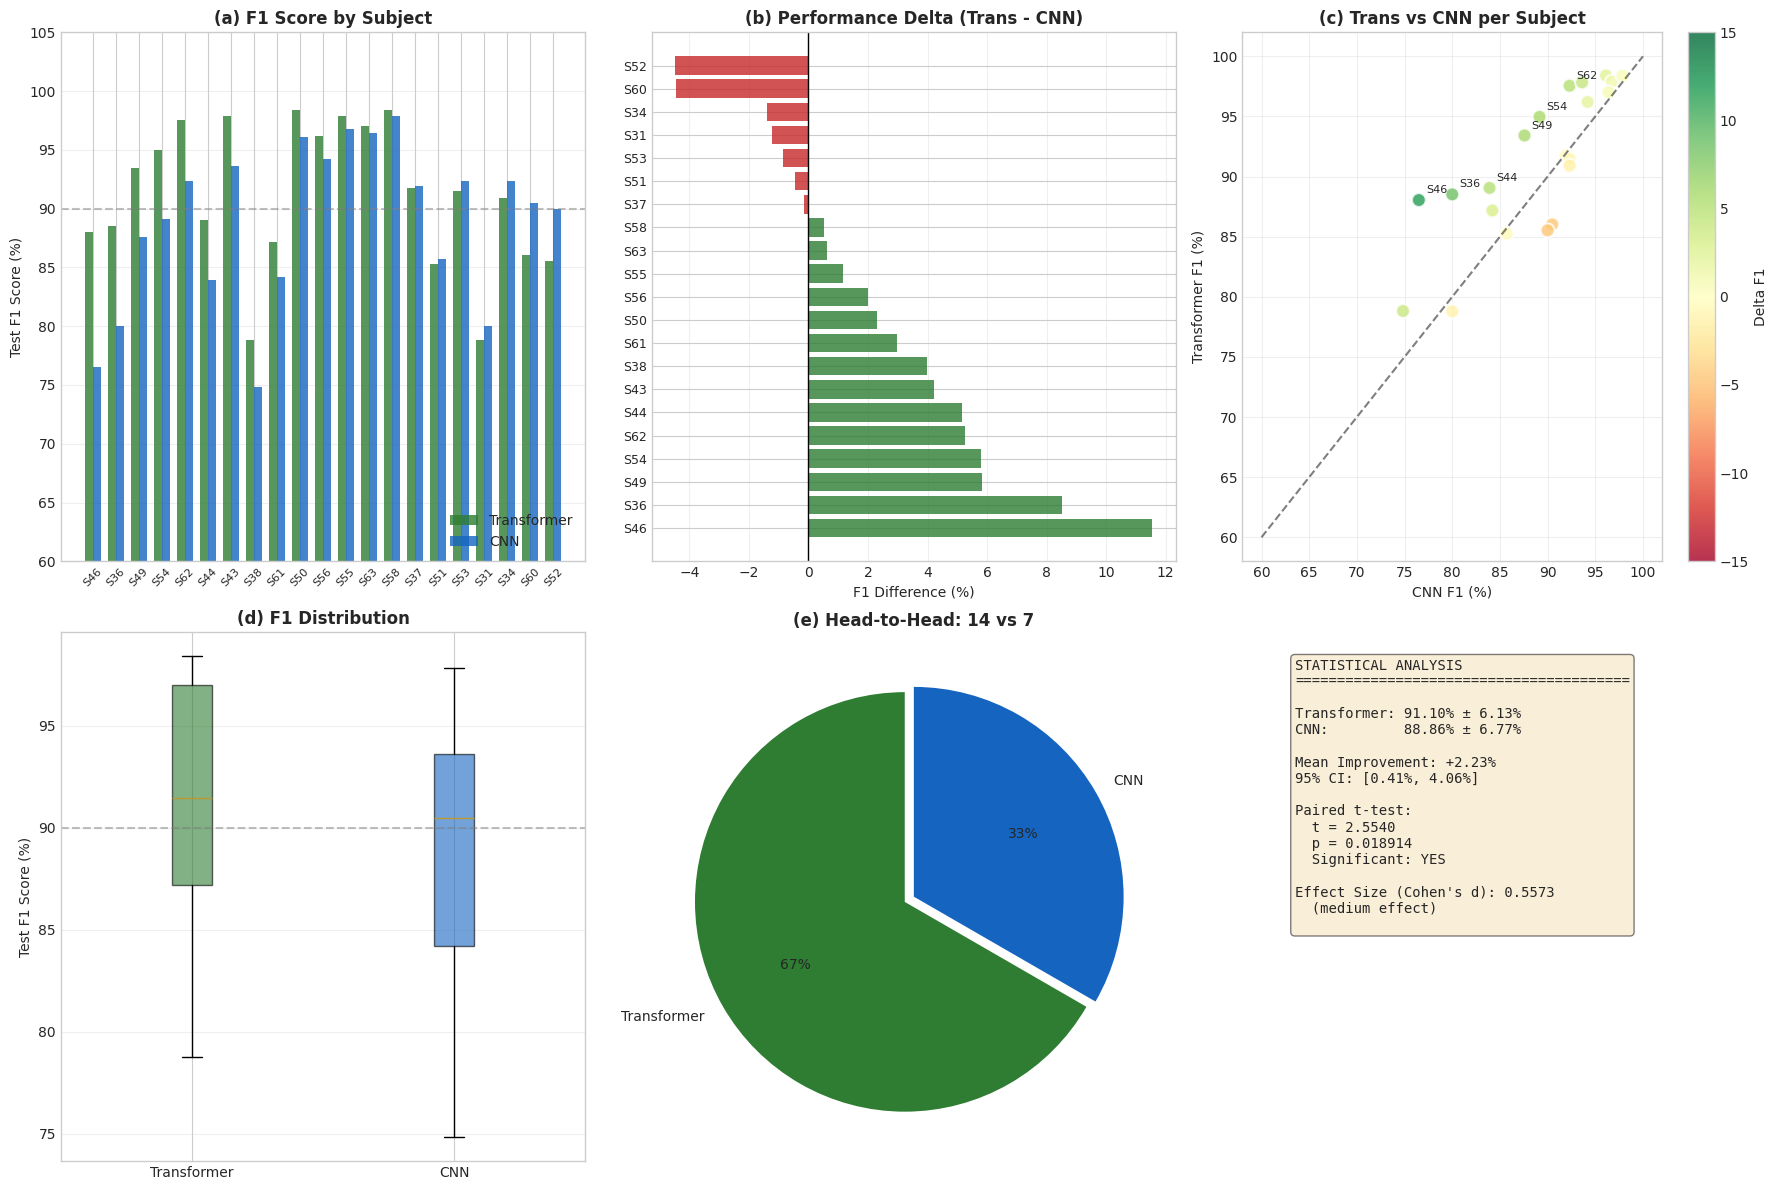

Saved: /home/abheekp/FusionTransformer/notebooks/analysis/figures/fig1_subject_overview.png


In [4]:
# Comprehensive subject-level visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. F1 Score Comparison
ax = axes[0, 0]
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['trans_f1'], width, label='Transformer', color='#2E7D32', alpha=0.8)
ax.bar(x + width/2, comparison['cnn_f1'], width, label='CNN', color='#1565C0', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"S{int(s)}" for s in comparison['subject']], rotation=45, fontsize=8)
ax.set_ylabel('Test F1 Score (%)')
ax.set_title('(a) F1 Score by Subject', fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(60, 105)
ax.grid(axis='y', alpha=0.3)

# 2. F1 Delta
ax = axes[0, 1]
colors = ['#2E7D32' if d > 0 else '#C62828' for d in comparison['delta_f1']]
ax.barh(range(len(comparison)), comparison['delta_f1'], color=colors, alpha=0.8)
ax.set_yticks(range(len(comparison)))
ax.set_yticklabels([f"S{int(s)}" for s in comparison['subject']], fontsize=9)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('F1 Difference (%)')
ax.set_title('(b) Performance Delta (Trans - CNN)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 3. Scatter plot
ax = axes[0, 2]
scatter = ax.scatter(comparison['cnn_f1'], comparison['trans_f1'],
                     c=comparison['delta_f1'], cmap='RdYlGn', s=100, alpha=0.8,
                     edgecolors='white', linewidth=1.5, vmin=-15, vmax=15)
ax.plot([60, 100], [60, 100], 'k--', alpha=0.5)
ax.set_xlabel('CNN F1 (%)')
ax.set_ylabel('Transformer F1 (%)')
ax.set_title('(c) Trans vs CNN per Subject', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Delta F1')
for _, row in comparison.iterrows():
    if abs(row['delta_f1']) > 5:
        ax.annotate(f"S{int(row['subject'])}", (row['cnn_f1'], row['trans_f1']),
                   textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.grid(alpha=0.3)

# 4. Box plots
ax = axes[1, 0]
bp = ax.boxplot([comparison['trans_f1'], comparison['cnn_f1']],
                labels=['Transformer', 'CNN'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2E7D32')
bp['boxes'][1].set_facecolor('#1565C0')
for box in bp['boxes']:
    box.set_alpha(0.6)
ax.set_ylabel('Test F1 Score (%)')
ax.set_title('(d) F1 Distribution', fontweight='bold')
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

# 5. Win rate pie
ax = axes[1, 1]
trans_wins = (comparison['winner'] == 'Transformer').sum()
cnn_wins = (comparison['winner'] == 'CNN').sum()
ax.pie([trans_wins, cnn_wins], labels=['Transformer', 'CNN'],
       colors=['#2E7D32', '#1565C0'], autopct='%1.0f%%', startangle=90, explode=(0.05, 0))
ax.set_title(f'(e) Head-to-Head: {trans_wins} vs {cnn_wins}', fontweight='bold')

# 6. Statistical summary
ax = axes[1, 2]
ax.axis('off')
t_stat, p_val = stats.ttest_rel(comparison['trans_f1'], comparison['cnn_f1'])
diff = comparison['trans_f1'] - comparison['cnn_f1']
cohens_d = diff.mean() / diff.std()
mean_diff = diff.mean()
se = diff.std() / np.sqrt(len(diff))
ci_95 = stats.t.interval(0.95, len(diff)-1, loc=mean_diff, scale=se)

summary = f"""STATISTICAL ANALYSIS
{'='*40}

Transformer: {comparison['trans_f1'].mean():.2f}% ± {comparison['trans_f1'].std():.2f}%
CNN:         {comparison['cnn_f1'].mean():.2f}% ± {comparison['cnn_f1'].std():.2f}%

Mean Improvement: {mean_diff:+.2f}%
95% CI: [{ci_95[0]:.2f}%, {ci_95[1]:.2f}%]

Paired t-test:
  t = {t_stat:.4f}
  p = {p_val:.6f}
  Significant: {'YES' if p_val < 0.05 else 'NO'}

Effect Size (Cohen's d): {cohens_d:.4f}
  ({('large' if abs(cohens_d) >= 0.8 else ('medium' if abs(cohens_d) >= 0.5 else 'small'))} effect)
"""
ax.text(0.1, 0.95, summary, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_subject_overview.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig1_subject_overview.png'}")

---
## Section 2: Trial Feature Analysis (if raw data available)
---

In [5]:
# Check if raw data is available for trial-level analysis
HAS_RAW_DATA = DATA_DIR.exists() and (DATA_DIR / 'young').exists()

if HAS_RAW_DATA:
    print("Raw sensor data available - can perform trial-level analysis")
    
    # Check for pre-computed features
    features_file = TABLES_DIR / 'trial_features.csv'
    if features_file.exists():
        print(f"Loading pre-computed features from {features_file}")
        features_df = pd.read_csv(features_file)
    else:
        print("Building trial features dataset (this may take a minute)...")
        
        # Define helper if not imported
        def load_trial_local(subject_id, activity_id, trial_id, sensor='watch'):
            result = {}
            for modality in ['accelerometer', 'gyroscope']:
                for age_group in ['young', 'old']:
                    path = DATA_DIR / age_group / modality / sensor / f'S{subject_id}A{activity_id}T{trial_id:02d}.csv'
                    if path.exists():
                        df = pd.read_csv(path, header=None)
                        if len(df.columns) >= 4:
                            df.columns = ['time', 'x', 'y', 'z'][:len(df.columns)]
                            for col in ['x', 'y', 'z']:
                                df[col] = pd.to_numeric(df[col], errors='coerce')
                            df = df.dropna()
                        if len(df) > 0:
                            result[modality] = df
                        break
            return result if 'accelerometer' in result else None
        
        def get_trials_local(subject_id, activity_id):
            trials = []
            for trial in range(1, 10):
                for age_group in ['young', 'old']:
                    path = DATA_DIR / age_group / 'accelerometer' / 'watch' / f'S{subject_id}A{activity_id}T{trial:02d}.csv'
                    if path.exists():
                        trials.append(trial)
                        break
            return trials
        
        def compute_features_local(acc, gyro=None, fs=30.0):
            features = {}
            ax = pd.to_numeric(acc['x'], errors='coerce').values
            ay = pd.to_numeric(acc['y'], errors='coerce').values
            az = pd.to_numeric(acc['z'], errors='coerce').values
            valid = ~(np.isnan(ax) | np.isnan(ay) | np.isnan(az))
            ax, ay, az = ax[valid], ay[valid], az[valid]
            if len(ax) == 0:
                return features
            smv = np.sqrt(ax**2 + ay**2 + az**2)
            features['smv_max'] = smv.max()
            features['smv_std'] = smv.std()
            features['smv_range'] = smv.max() - smv.min()
            features['duration_s'] = len(smv) / fs
            peaks, _ = find_peaks(smv, height=15, prominence=5)
            features['n_impact_peaks'] = len(peaks)
            if gyro is not None and len(gyro) > 0:
                try:
                    gx = pd.to_numeric(gyro['x'], errors='coerce').values
                    gy = pd.to_numeric(gyro['y'], errors='coerce').values
                    gz = pd.to_numeric(gyro['z'], errors='coerce').values
                    valid_g = ~(np.isnan(gx) | np.isnan(gy) | np.isnan(gz))
                    if valid_g.sum() > 0:
                        gx, gy, gz = gx[valid_g], gy[valid_g], gz[valid_g]
                        gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)
                        features['gyro_max'] = gyro_mag.max()
                        features['gyro_std'] = gyro_mag.std()
                        features['total_rotation_deg'] = np.sum(np.abs(gyro_mag)) / fs
                except:
                    pass
            if len(ax) > 1:
                jerk = np.sqrt(np.diff(ax)**2 + np.diff(ay)**2 + np.diff(az)**2) * fs
                features['jerk_max'] = jerk.max()
            return features
        
        # Build features
        all_features = []
        for subj in comparison['subject'].values:
            subj = int(subj)
            for act_id, act_name in FALL_ACTIVITIES.items():
                trials = get_trials_local(subj, act_id)
                for trial in trials:
                    data = load_trial_local(subj, act_id, trial)
                    if data and 'accelerometer' in data:
                        feats = compute_features_local(data['accelerometer'], data.get('gyroscope'))
                        feats['subject'] = subj
                        feats['activity_id'] = act_id
                        feats['activity_name'] = act_name
                        feats['trial'] = trial
                        all_features.append(feats)
        
        features_df = pd.DataFrame(all_features)
        features_df = features_df.merge(comparison[['subject', 'trans_f1', 'cnn_f1', 'delta_f1', 'winner']], on='subject')
        
        # Save for future use
        features_df.to_csv(features_file, index=False)
        print(f"Saved features to {features_file}")
    
    print(f"\nTotal trials: {len(features_df)}")
    print(f"Trials per activity:\n{features_df.groupby('activity_name').size()}")
else:
    print("Raw sensor data not available")
    print("Checking for pre-computed features...")
    features_file = TABLES_DIR / 'trial_features.csv'
    if features_file.exists():
        features_df = pd.read_csv(features_file)
        print(f"Loaded {len(features_df)} pre-computed trial features")
        HAS_RAW_DATA = True  # We can still do feature analysis
    else:
        print("No pre-computed features found. Trial-level analysis will be skipped.")
        features_df = None

Raw sensor data available - can perform trial-level analysis
Loading pre-computed features from /home/abheekp/FusionTransformer/notebooks/analysis/tables/trial_features.csv

Total trials: 453
Trials per activity:
activity_name
Backfall      97
Frontfall     86
Leftfall      96
Rightfall     83
Rotatefall    91
dtype: int64


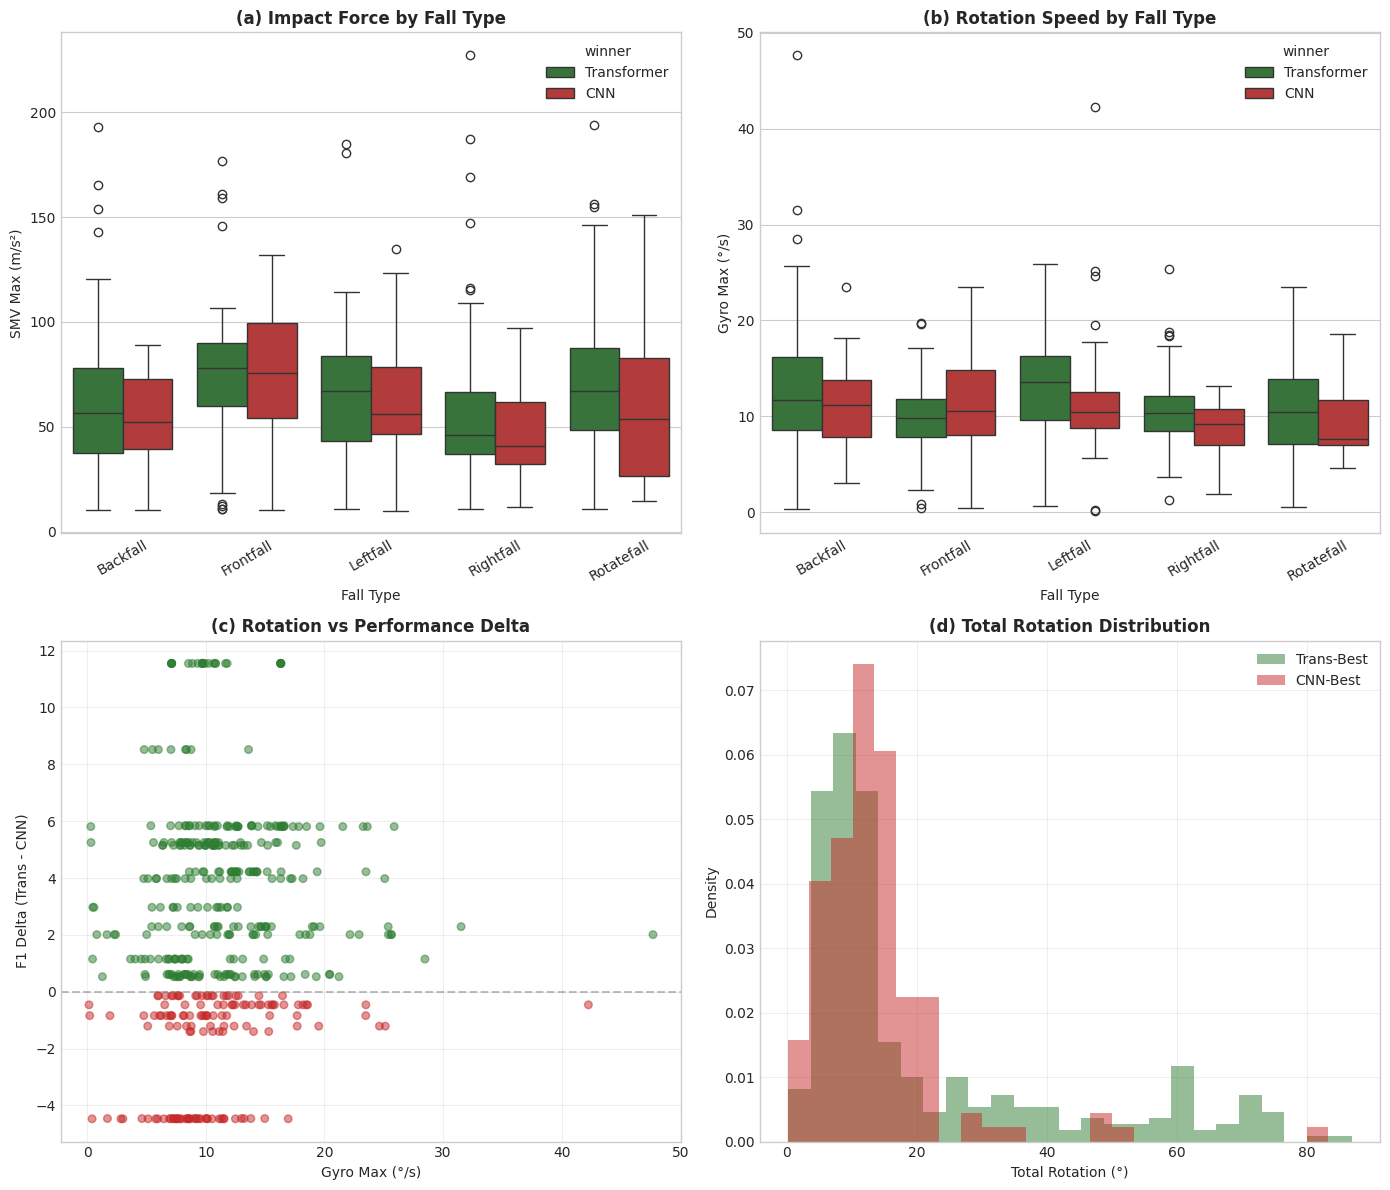

Saved: /home/abheekp/FusionTransformer/notebooks/analysis/figures/fig2_activity_analysis.png


In [6]:
# Activity-level analysis (if features available)
if features_df is not None and len(features_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # SMV Max by activity
    ax = axes[0, 0]
    sns.boxplot(x='activity_name', y='smv_max', hue='winner', data=features_df, ax=ax,
                palette={'Transformer': '#2E7D32', 'CNN': '#C62828'})
    ax.set_xlabel('Fall Type')
    ax.set_ylabel('SMV Max (m/s²)')
    ax.set_title('(a) Impact Force by Fall Type', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    
    # Gyro Max by activity
    ax = axes[0, 1]
    if 'gyro_max' in features_df.columns:
        sns.boxplot(x='activity_name', y='gyro_max', hue='winner', data=features_df, ax=ax,
                    palette={'Transformer': '#2E7D32', 'CNN': '#C62828'})
        ax.set_xlabel('Fall Type')
        ax.set_ylabel('Gyro Max (°/s)')
        ax.set_title('(b) Rotation Speed by Fall Type', fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
    
    # Feature correlation
    ax = axes[1, 0]
    if 'gyro_max' in features_df.columns:
        ax.scatter(features_df['gyro_max'], features_df['delta_f1'],
                   c=['#2E7D32' if w == 'Transformer' else '#C62828' for w in features_df['winner']],
                   s=30, alpha=0.5)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Gyro Max (°/s)')
        ax.set_ylabel('F1 Delta (Trans - CNN)')
        ax.set_title('(c) Rotation vs Performance Delta', fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Feature distributions
    ax = axes[1, 1]
    trans_feats = features_df[features_df['winner'] == 'Transformer']
    cnn_feats = features_df[features_df['winner'] == 'CNN']
    if 'total_rotation_deg' in features_df.columns:
        ax.hist(trans_feats['total_rotation_deg'].dropna(), bins=25, alpha=0.5, color='#2E7D32', label='Trans-Best', density=True)
        ax.hist(cnn_feats['total_rotation_deg'].dropna(), bins=25, alpha=0.5, color='#C62828', label='CNN-Best', density=True)
        ax.set_xlabel('Total Rotation (°)')
        ax.set_ylabel('Density')
        ax.set_title('(d) Total Rotation Distribution', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig2_activity_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIGURES_DIR / 'fig2_activity_analysis.png'}")
else:
    print("Skipping activity analysis (no trial features available)")

---
## Section 3: Key Findings Summary
---

In [7]:
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

print(f"""
1. OVERALL PERFORMANCE
{'-'*50}
   Dual-Stream Transformer: {comparison['trans_f1'].mean():.2f}% ± {comparison['trans_f1'].std():.2f}%
   CNN Kalman:              {comparison['cnn_f1'].mean():.2f}% ± {comparison['cnn_f1'].std():.2f}%
   Mean Improvement:        {(comparison['trans_f1'] - comparison['cnn_f1']).mean():+.2f}%

2. HEAD-TO-HEAD
{'-'*50}
   Transformer WINS: {(comparison['winner'] == 'Transformer').sum()}/{len(comparison)} subjects
   CNN WINS:         {(comparison['winner'] == 'CNN').sum()}/{len(comparison)} subjects

3. TOP SUBJECTS
{'-'*50}
   Best Transformer:
""")

for _, row in comparison.head(3).iterrows():
    print(f"      S{int(row['subject'])}: {row['trans_f1']:.1f}% vs {row['cnn_f1']:.1f}% (Δ = {row['delta_f1']:+.1f}%)")

print("\n   Best CNN:")
for _, row in comparison.tail(3).iterrows():
    print(f"      S{int(row['subject'])}: {row['trans_f1']:.1f}% vs {row['cnn_f1']:.1f}% (Δ = {row['delta_f1']:+.1f}%)")

if features_df is not None and 'total_rotation_deg' in features_df.columns:
    trans_feats = features_df[features_df['winner'] == 'Transformer']
    cnn_feats = features_df[features_df['winner'] == 'CNN']
    print(f"""
4. SIGNAL CHARACTERISTICS
{'-'*50}
   Transformer-best subjects:
      Total Rotation: {trans_feats['total_rotation_deg'].mean():.1f}° (mean)
      Gyro Max:       {trans_feats['gyro_max'].mean():.1f} °/s (mean)
   CNN-best subjects:
      Total Rotation: {cnn_feats['total_rotation_deg'].mean():.1f}° (mean)
      Gyro Max:       {cnn_feats['gyro_max'].mean():.1f} °/s (mean)
""")

print(f"""
5. CONCLUSION
{'-'*50}
   The Dual-Stream Kalman Transformer excels on subjects with
   higher rotational velocity during falls. The Kalman orientation
   fusion provides meaningful features that the transformer's
   self-attention mechanism can leverage effectively.
""")

# Save comparison table
comparison.to_csv(TABLES_DIR / 'subject_comparison.csv', index=False)
print(f"\nTables saved to: {TABLES_DIR}")

KEY FINDINGS SUMMARY

1. OVERALL PERFORMANCE
--------------------------------------------------
   Dual-Stream Transformer: 91.10% ± 6.13%
   CNN Kalman:              88.86% ± 6.77%
   Mean Improvement:        +2.23%

2. HEAD-TO-HEAD
--------------------------------------------------
   Transformer WINS: 14/21 subjects
   CNN WINS:         7/21 subjects

3. TOP SUBJECTS
--------------------------------------------------
   Best Transformer:

      S46: 88.0% vs 76.5% (Δ = +11.5%)
      S36: 88.5% vs 80.0% (Δ = +8.5%)
      S49: 93.4% vs 87.6% (Δ = +5.8%)

   Best CNN:
      S34: 90.9% vs 92.3% (Δ = -1.4%)
      S60: 86.0% vs 90.5% (Δ = -4.5%)
      S52: 85.5% vs 90.0% (Δ = -4.5%)

4. SIGNAL CHARACTERISTICS
--------------------------------------------------
   Transformer-best subjects:
      Total Rotation: 20.7° (mean)
      Gyro Max:       11.6 °/s (mean)
   CNN-best subjects:
      Total Rotation: 13.6° (mean)
      Gyro Max:       10.7 °/s (mean)


5. CONCLUSION
-------------------

In [8]:
# List all generated outputs
print("\n" + "="*60)
print("GENERATED OUTPUTS")
print("="*60)

print(f"\nFigures ({FIGURES_DIR}):")
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f"  - {f.name}")

print(f"\nTables ({TABLES_DIR}):")
for f in sorted(TABLES_DIR.glob('*.csv')):
    print(f"  - {f.name}")

print(f"\nTrial Plots ({TRIAL_PLOTS_DIR}):")
n_plots = len(list(TRIAL_PLOTS_DIR.rglob('*.png')))
print(f"  {n_plots} individual trial plots")


GENERATED OUTPUTS

Figures (/home/abheekp/FusionTransformer/notebooks/analysis/figures):
  - fig1_subject_level_overview.png
  - fig1_subject_overview.png
  - fig2_activity_analysis.png
  - fig2_activity_level_analysis.png
  - fig3_feature_correlations.png
  - fig4_feature_distributions.png
  - summary_overview.png

Tables (/home/abheekp/FusionTransformer/notebooks/analysis/tables):
  - per_subject_comparison.csv
  - subject_comparison.csv
  - trial_features.csv

Trial Plots (/home/abheekp/FusionTransformer/notebooks/analysis/trial_plots):
  150 individual trial plots
